Hotel Fake Review Detection: Baseline Models
1. Load cleaned Dataset

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the cleaned dataset
hotel_df = pd.read_csv('../data/processed/hotel_final_clean.csv')
X = hotel_df['text']
Y = hotel_df['label']

2. Train/Test data

In [4]:
# Split the dataset into training and testing sets
X_train_text, X_test_text, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)


3. TF-IDF vectorization

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

4. Logistic Regression Training
Use Logistic Regression for classification

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Train the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, Y_train)
# Make predictions on the test set
Y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Performance:")
print(classification_report(Y_test, Y_pred_lr))
print("Accuracy:", accuracy_score(Y_test, Y_pred_lr))


Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.89      0.86      0.87       160
           1       0.86      0.89      0.88       160

    accuracy                           0.88       320
   macro avg       0.88      0.88      0.87       320
weighted avg       0.88      0.88      0.87       320

Accuracy: 0.875


5. Random Forest Training

In [7]:
from sklearn.ensemble import RandomForestClassifier
# Train the Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)
# Make predictions on the test set
Y_pred_rf = rf.predict(X_test)

print("Random Forest Performance:")
print(classification_report(Y_test, Y_pred_rf))
print("Accuracy:", accuracy_score(Y_test, Y_pred_rf))

Random Forest Performance:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       160
           1       0.81      0.84      0.82       160

    accuracy                           0.82       320
   macro avg       0.82      0.82      0.82       320
weighted avg       0.82      0.82      0.82       320

Accuracy: 0.821875


6. Baseline Model Evaluation – Confusion Matrices

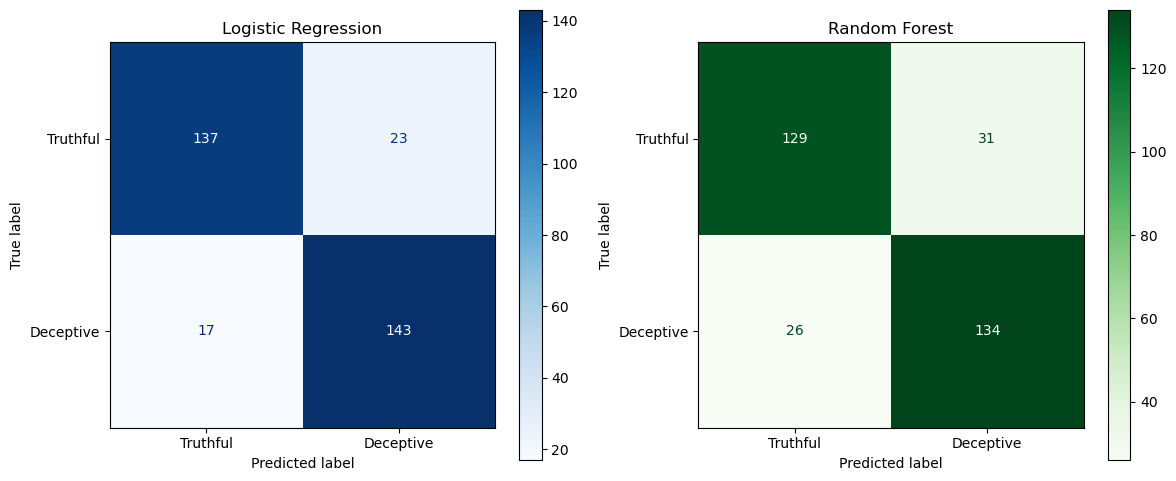

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix for Logistic Regression
ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred_lr, ax=axs[0], cmap='Blues', display_labels=['Truthful', 'Deceptive'])
axs[0].set_title('Logistic Regression')

# Confusion Matrix for Random Forest
ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred_rf, ax=axs[1], display_labels=['Truthful', 'Deceptive'], cmap='Greens')
axs[1].set_title('Random Forest')

plt.tight_layout()
plt.show()

7. Summary
- Train/test split is stratified to maintain class balance.
- TF-IDF is used to convert text into numerical features for both models.
- Logistic Regression is simple, fast, and provides strong baseline performance.
- Random Forest handles non-linear relationships and may perform better with noisy data.
- This notebook establishes a baseline for comparison with deep learning models such as BERT 